# bagpus quickstart: mock recovery in minutes

**bagpus** (Bayesian Analysis of Galaxy PopUlations with Spectra) infers the *population-level* distributions of galaxy physical parameters — star formation histories, dust, metallicity — by fitting the observed distribution of an entire survey at once, using simulation-based inference (SBI) with [bagpipes](https://github.com/ACCarnall/bagpipes) as the forward model of individual galaxies.

This notebook demonstrates the full workflow on a **mock dataset**, so it needs no survey catalogue and runs in a few minutes on a laptop:

1. define a population model,
2. simulate training data,
3. train the neural posterior,
4. generate a mock observation with known parameters,
5. recover those parameters.

The simulation sizes here are deliberately tiny — results will be noisy. For science, scale up `nsims` and `ngal_sims` (see the UDS walkthrough notebook).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import bagpus

# use the stellar grids shipped with your bagpipes installation, or switch
# with bagpus.grids.change_grid(...) — see the documentation

## 1. A synthetic observed sample

`Observations` normally holds your survey: super-colours, their errors, and redshifts. Here we invent a plausible sample: redshifts uniform in $1.7<z<2$, a plausible range of super-colours, and super-colour errors drawn to mimic a magnitude-limited survey (larger errors for redder SC1, as fainter red galaxies are noisier).

The eigenbasis files shipped in the repository (`UDS/VWSC_eigenbasis_0p5z3_wavemin2500.fits`, `FILTERS/`) define how model spectra are projected onto super-colours. Note you can't change the filters without computing a new eigenbasis file. 

In [2]:
rng = np.random.default_rng(42)
n_mock = 2000

redshifts = rng.uniform(1.7, 2.0, n_mock)

# fake super-colours only inform the noise model, not the fit itself
sc = np.stack([rng.uniform(-40, 90, n_mock), rng.uniform(-20, 30, n_mock)], axis=1)
sc_err = np.stack([0.5 + 0.01 * (sc[:, 0] + 50) + rng.normal(0, 0.1, n_mock),
                   0.5 + 0.005 * (sc[:, 0] + 50) + rng.normal(0, 0.05, n_mock)], axis=1)
sc_err = np.abs(sc_err) + 0.05

obs = bagpus.Observations(
    sc=sc, sc_err=sc_err, redshifts=redshifts,
    eigenbasis_file='../UDS/VWSC_eigenbasis_0p5z3_wavemin2500.fits',
    filter_list_file='../FILTERS/vwsc_uds.lis',
    filter_dir='../FILTERS/',
    n_eigenvectors=3,
    filter_mask=[9, 10],   # HST bands in the filter list not used in the data
    zmin=1.7, zmax=2.0,
)
print(len(obs), 'galaxies')

10 eigenvectors extracted
Minimum redshift of the eigenbasis: 0.5
Maximum redshift of the eigenbasis: 3.0
2000 galaxies


## 2. The population model

Each galaxy-level parameter is drawn from a truncated Gaussian; the *population mean and SD* of each Gaussian are the quantities we infer, with flat hyperpriors given by `mu` and `sigma`.

The `"type"` entries select the SFH and dust models from the registries in `bagpus.models` — currently `dblplaw` (double power-law with the falling slope expressed as a quenching half-life $\tau_{1/2}$) and `Calzetti` (with an Av–sSFR relation). Adding new models is a small amount of code: see the *Adding a new model* documentation page.

In [3]:
t_zmax = obs_age = 3.5  # ~ age of Universe at z=2 (Gyr); sets the SFH peak-time prior

pop_instructions = {
    "sfh": {
        "type": "dblplaw",
        "tau":        {"limits": (0.2, 1.5 * t_zmax), "mu": (2.0, 4.0), "sigma": (0.5, 2.0)},
        "logbeta":    {"limits": (-1.0, 2.0), "mu": (-1.0, 3.0), "sigma": (0.5, 2.0)},
        "logtauhalf": {"limits": (-2.0, 1.0), "mu": (-2.0, 1.0), "sigma": (0.1, 1.0)},
    },
    "dust": {
        "type": "Calzetti",
        "eta":      {"limits": (1.0, 3.0), "mu": (1.0, 2.0), "sigma": (0.2, 2.0)},
        "logAvint": {"limits": (0.8, 2.0), "mu": (1.2, 1.5), "sigma": (0.1, 0.2)},
    },
    "metallicity": {"limits": (0.5, 2.5), "mu": (0.5, 2.0), "sigma": (0.2, 2.0)},
}

model = bagpus.PopulationModel(pop_instructions, obs)
print('population parameters:', model.param_names)
print('inferred hyperparameters:', model.n_hyper)

population parameters: ['sfh_tau', 'sfh_logbeta', 'sfh_logtauhalf', 'dust_eta', 'dust_logAvint', 'Zmet']
inferred hyperparameters: 12


## 3. Simulate training data and train the posterior

`Fit` manages the workflow and caches every product under `runs/<run>/`, so re-running a cell is cheap and an interrupted session can resume.

With 60 simulations of 200 galaxies this takes a few minutes; posterior quality scales with both numbers.

Most mac laptops have ~8-12 cores, but you can change ncores to suit the machine you are working on. If you choose a number larger than your machine has, the code should still work with your maximum number of cores. Use "top" or "Activity Monitor" to check that you are running the number of processes you think you are. 

In [4]:
fit = bagpus.Fit(model, run='quickstart', ngal_sims=200, ncores=8)

fit.simulate(nsims=60)      # slow cell: ~minutes
fit.simulate_test(nsims=5)
posterior = fit.train(n_pca_components=10)

Simulating training batch 1 (60 simulations, 200 galaxies each)...


/Users/vw8/Research/Projects/bagpus_claude/bagpus/utils.py:102: RuntimeWarning: invalid value encountered in divide
  ssfr = sfh.sfh / cummass
/Users/vw8/Research/Projects/bagpus_claude/bagpus/utils.py:102: RuntimeWarning: invalid value encountered in divide
  ssfr = sfh.sfh / cummass
/Users/vw8/Research/Projects/bagpus_claude/bagpus/utils.py:102: RuntimeWarning: invalid value encountered in divide
  ssfr = sfh.sfh / cummass
/Users/vw8/Research/Projects/bagpus_claude/bagpus/utils.py:102: RuntimeWarning: invalid value encountered in divide
  ssfr = sfh.sfh / cummass
/Users/vw8/Research/Projects/bagpus_claude/bagpus/utils.py:102: RuntimeWarning: invalid value encountered in divide
  ssfr = sfh.sfh / cummass
/Users/vw8/Research/Projects/bagpus_claude/bagpus/utils.py:102: RuntimeWarning: invalid value encountered in divide
  ssfr = sfh.sfh / cummass
/Users/vw8/Research/Projects/bagpus_claude/bagpus/utils.py:81: RuntimeWarning: invalid value encountered in divide
  ssfr = sfh.sfh / cummass


/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1
/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1
/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1
/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


...

/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/a

Training neural posterior estimator...



 Training neural network. Epochs trained: 1
 Training neural network. Epochs trained: 2
 Training neural network. Epochs trained: 3
 Training neural network. Epochs trained: 4
 Training neural network. Epochs trained: 5
 Training neural network. Epochs trained: 6
 Training neural network. Epochs trained: 7
 Training neural network. Epochs trained: 8
 Training neural network. Epochs trained: 9
 Training neural network. Epochs trained: 10
 Training neural network. Epochs trained: 11
 Training neural network. Epochs trained: 12
 Training neural network. Epochs trained: 13
 Training neural network. Epochs trained: 14
 Training neural network. Epochs trained: 15
 Training neural network. Epochs trained: 16
 Training neural network. Epochs trained: 17
 Training neural network. Epochs trained: 18
 Training neural network. Epochs trained: 19
 Training neural network. Epochs trained: 20
 Training neural network. Epochs trained: 21
 Training neural network. Epochs trained: 22
 Training neural n


 Training neural network. Epochs trained: 49
 Training neural network. Epochs trained: 50
 Training neural network. Epochs trained: 51
 Training neural network. Epochs trained: 52
 Training neural network. Epochs trained: 53
 Training neural network. Epochs trained: 54
 Training neural network. Epochs trained: 55
 Training neural network. Epochs trained: 56
 Training neural network. Epochs trained: 57
 Training neural network. Epochs trained: 58
 Training neural network. Epochs trained: 59
 Training neural network. Epochs trained: 60
 Training neural network. Epochs trained: 61
 Training neural network. Epochs trained: 62
 Training neural network. Epochs trained: 63
 Training neural network. Epochs trained: 64
 Training neural network. Epochs trained: 65
 Training neural network. Epochs trained: 66
 Training neural network. Epochs trained: 67
 Training neural network. Epochs trained: 68
 Training neural network. Epochs trained: 69
 Training neural network. Epochs trained: 70
 Training


 Training neural network. Epochs trained: 103
 Training neural network. Epochs trained: 104
 Training neural network. Epochs trained: 105
 Training neural network. Epochs trained: 106
 Training neural network. Epochs trained: 107
 Training neural network. Epochs trained: 108
 Training neural network. Epochs trained: 109
 Training neural network. Epochs trained: 110
 Training neural network. Epochs trained: 111
 Training neural network. Epochs trained: 112
 Training neural network. Epochs trained: 113
 Training neural network. Epochs trained: 114
 Training neural network. Epochs trained: 115
 Training neural network. Epochs trained: 116
 Training neural network. Epochs trained: 117
 Training neural network. Epochs trained: 118
 Training neural network. Epochs trained: 119
 Training neural network. Epochs trained: 120
 Training neural network. Epochs trained: 121
 Training neural network. Epochs trained: 122
 Training neural network. Epochs trained: 123
 Neural network successfully conv

## 4. A mock observation with known parameters

We pick a "true" hyperparameter vector, forward-simulate its SC distribution, and treat that as the observed data.

Bagpipes: Latex turned off in rcParams, plots may look strange.


Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


/Users/vw8/Research/Projects/bagpus_claude/bagpus/utils.py:102: RuntimeWarning: invalid value encountered in divide
  ssfr = sfh.sfh / cummass
/Users/vw8/Research/Projects/bagpus_claude/bagpus/utils.py:81: RuntimeWarning: invalid value encountered in divide
  ssfr = sfh.sfh / cummass


ERROR IN SFH!! {'redshift': np.float64(1.9537390873406428), 'dust': {'type': 'Calzetti', 'Av': np.float64(1.4341707118213516), 'eta': np.float64(1.2716094653189913)}, 'nebular': {'logU': -3, 'velshift': 0.0}, 'dblplaw': {'tau': np.float64(4.994990899244287), 'alpha': np.float64(10.984477718044536), 'beta': np.float64(27.04453251228436), 'massformed': 10, 'metallicity': np.float64(0.8594993793680683)}}


/var/folders/fh/mdm91_1s3jd9226v2cqktxk40000gq/T/ipykernel_79911/2027238834.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.imshow(np.array(x_mock).T, cmap='GnBu', origin='lower', aspect='auto',


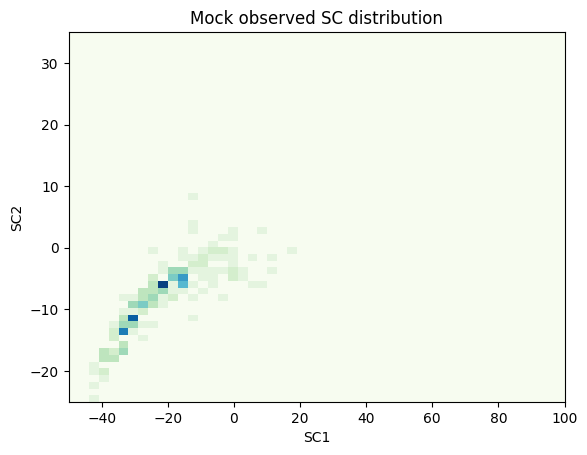

In [5]:
theta_true = np.array([
    2.5, 1.5,    # tau: mean, sd
    1.5, 1.0,    # logbeta
    0.3, 0.5,    # logtauhalf
    1.5, 0.5,    # eta
    1.4, 0.14,   # logAvint
    1.0, 0.5,    # metallicity
])

x_mock = bagpus.simulator.simulator_SC(theta_true, model, ngal=200)

plt.imshow(np.array(x_mock).T, cmap='GnBu', origin='lower', aspect='auto',
           extent=[obs.pdf_range[0][0], obs.pdf_range[0][1],
                   obs.pdf_range[1][0], obs.pdf_range[1][1]])
plt.xlabel('SC1'); plt.ylabel('SC2'); plt.title('Mock observed SC distribution');

## 5. Recover the parameters

Sample the trained posterior given the mock data, and compare with the truth (orange lines). With this tiny training set expect broad, noisy posteriors — but they should bracket the truth.

  0%|          | 0/500 [00:00<?, ?it/s]

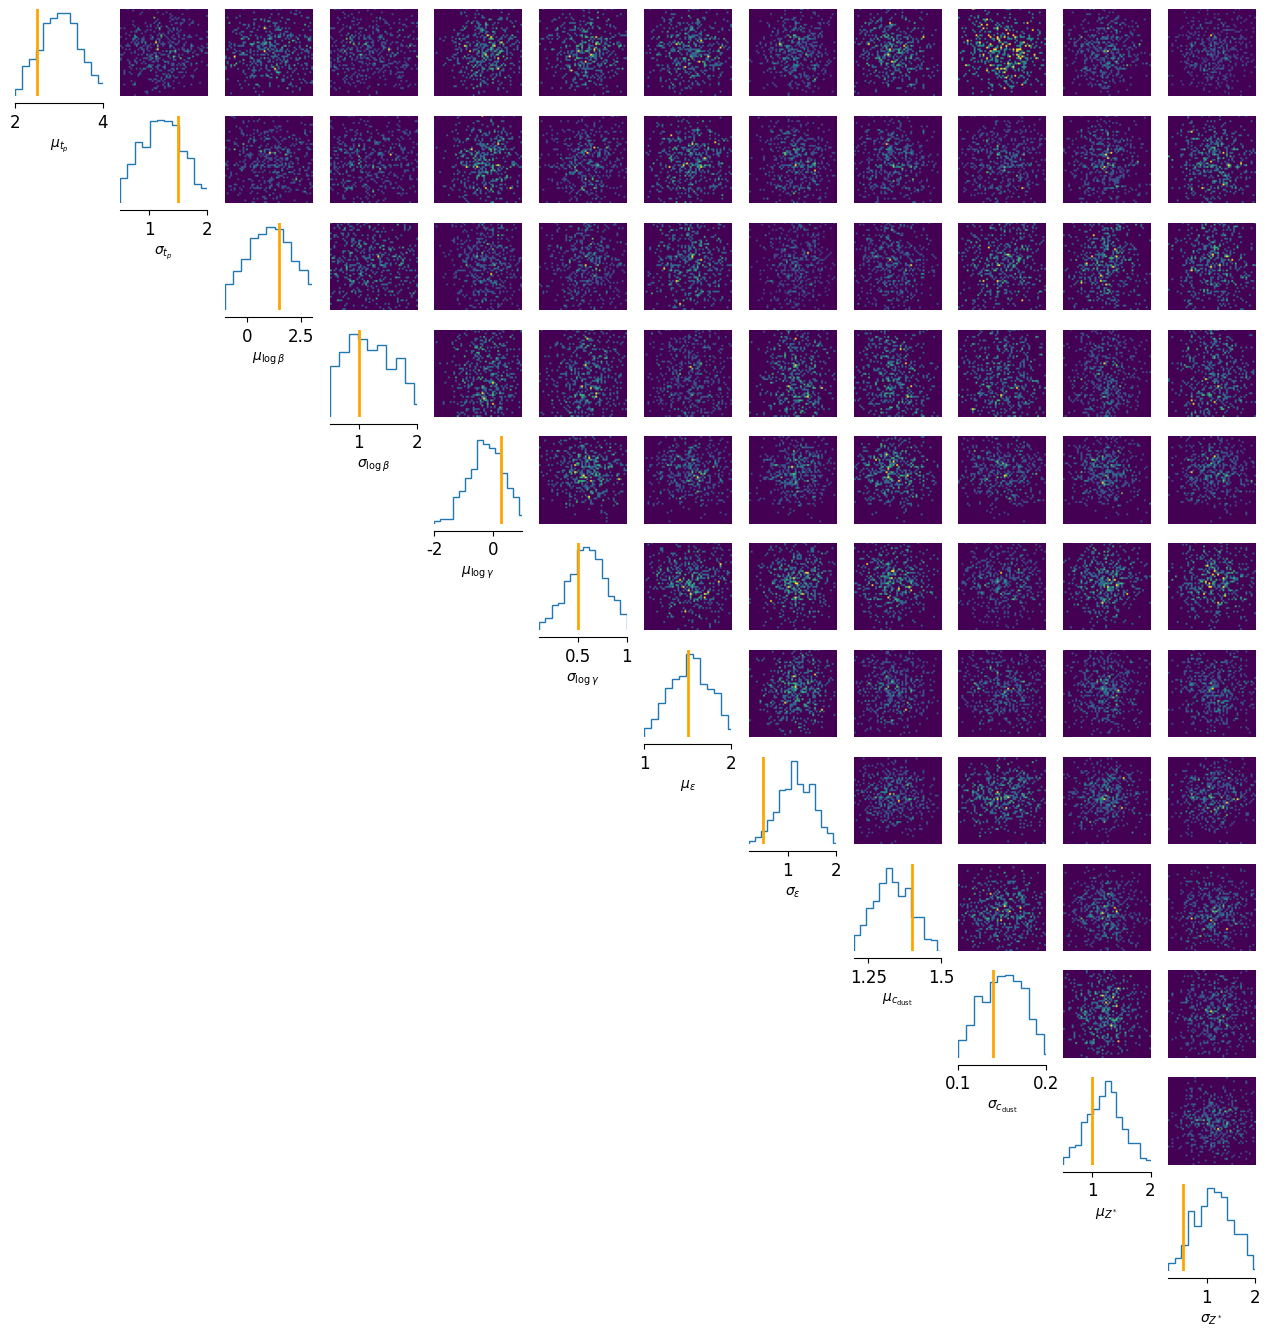

In [6]:
samples = fit.sample_mock(x_mock, n=500)

fig = fit.plot_corner(samples=samples)
axes = np.array(fig.axes).reshape(len(theta_true), len(theta_true))
for i, truth in enumerate(theta_true):
    axes[i, i].axvline(truth, color='orange', lw=2)

## Next steps

* Fit real data: see the **UDS walkthrough** notebook, which reproduces the release-paper analysis.
* Scale up: `nsims_train=5000`, `ngal_sims=7000` were used for the paper (hours on a multi-core machine — the `scripts/` folder runs the same workflow from the command line, batch by batch).
* Different SFH or dust model: subclass `bagpus.models.SFHModel` / `DustModel` and register it.